In [ ]:
#@title Imports & Utils

import pandas as pd
import ast
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from sklearn import metrics

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
distmult_test_preds = pd.read_csv("/content/distmult-test-preds.tsv", index_col=False, sep="\t").dropna().drop_duplicates().reset_index(drop=True)
distmult_val_preds = pd.read_csv("/content/distmult-val-preds.tsv", index_col=False, sep="\t").dropna().drop_duplicates().reset_index(drop=True)

roberta_test_preds = pd.read_csv("/content/roberta-test-preds.tsv", index_col=False, sep="\t").applymap(lambda x: x.strip()).dropna().drop_duplicates().reset_index(drop=True)
roberta_val_preds = pd.read_csv("/content/roberta-val-preds.tsv", index_col=False, sep="\t").applymap(lambda x: x.strip()).dropna().drop_duplicates().reset_index(drop=True)

In [ ]:
assert len(distmult_test_preds) == len(roberta_test_preds)
assert len(distmult_val_preds) == len(roberta_val_preds)

# **Data Exploration**

In [ ]:
dictionary = {label: idx for idx, label in enumerate(set(distmult_test_preds['true'].values.tolist()))}
labels = list(dictionary.keys())
dictionary

In [ ]:
distmult_test_preds.head()

,true,predicted,sentence1,sentence2
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared..."
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h..."
2,Support,noRel,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...
3,Attack,noRel,that's not the way this country ought to be run,"Mr. Ford, so far as I know, except for avoidin..."
4,Attack,Support,if we remain dependent on a source of energy t...,No matter how strong we are economically


In [ ]:
roberta_test_preds.head()

,true,predicted,sentence1,sentence2
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared..."
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h..."
2,Support,Support,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...
3,Attack,Attack,that's not the way this country ought to be run,"Mr. Ford, so far as I know, except for avoidin..."
4,Attack,Attack,if we remain dependent on a source of energy t...,No matter how strong we are economically


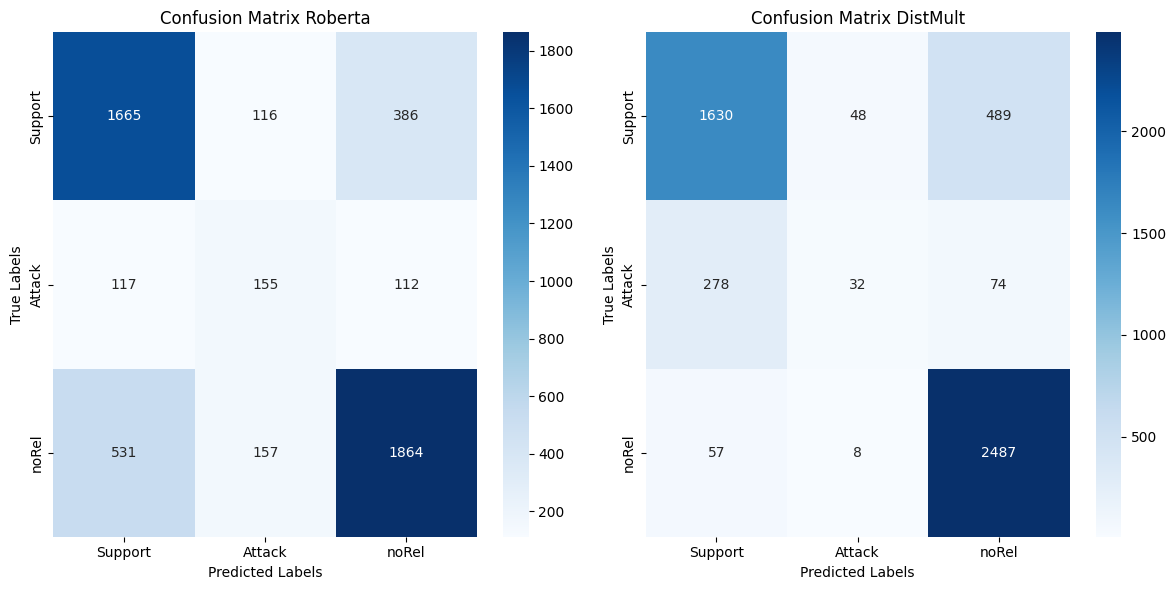

In [ ]:
# Plotting Confusion Matrix for Roberta - test dataset
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(roberta_test_preds['true'].map(lambda x: value_dict.get(x)), \
                             roberta_test_preds['predicted'].map(lambda x: value_dict.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Roberta - test set')

# Plotting Confusion Matrix for DistMult - test dataset
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(distmult_test_preds['true'].map(lambda x: value_dict.get(x)), \
                             distmult_test_preds['predicted'].map(lambda x: value_dict.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix DistMult - test set')

plt.tight_layout()
plt.show()

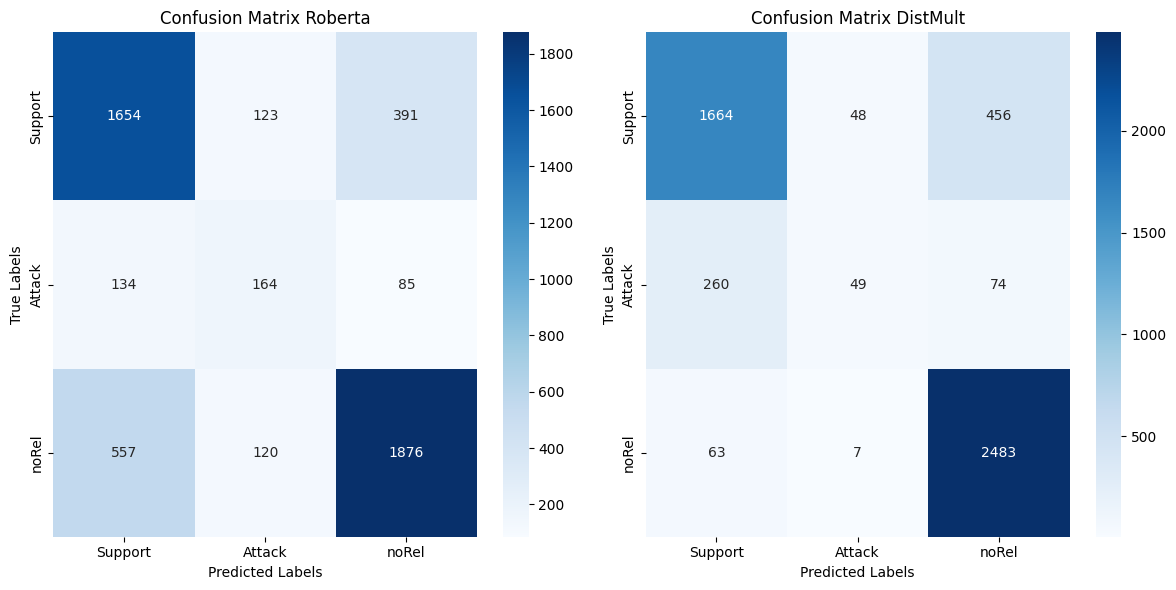

In [ ]:
# Plotting Confusion Matrix for Roberta - val dataset
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(roberta_val_preds['true'].map(lambda x: value_dict.get(x)), \
                             roberta_val_preds['predicted'].map(lambda x: value_dict.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Roberta - val set')

# Plotting Confusion Matrix for DistMult - val dataset
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(distmult_val_preds['true'].map(lambda x: value_dict.get(x)), \
                             distmult_val_preds['predicted'].map(lambda x: value_dict.get(x))), \
            annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix DistMult - val set')

plt.tight_layout()
plt.show()

In [ ]:
true = roberta_test_preds['true']
preds = roberta_test_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds)}")
print(f"Precision: {metrics.precision_score(true, preds)}")

0.6279085763640362

In [ ]:
true = distmult_test_preds['true']
preds = distmult_test_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds)}")
print(f"Precision: {metrics.precision_score(true, preds)}")

0.6041515273039656

In [ ]:
true = roberta_val_preds['true']
preds = roberta_val_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds)}")
print(f"Precision: {metrics.precision_score(true, preds)}")

0.6377057295391543

In [ ]:
true = distmult_val_preds['true']
preds = distmult_val_preds['predicted']
print(f"F1-macro: {metrics.f1_score(true, preds, average='macro')}")
print(f"F1-micro: {metrics.f1_score(true, preds, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(true, preds)}")
print(f"Recall: {metrics.recall_score(true, preds)}")
print(f"Precision: {metrics.precision_score(true, preds)}")

0.6314657958009401

# **In-Pipeline evaluation**
Simulating what will happen if models are stacked in a pipeline:


---



### 1.
Distmults predics which nodes don't have any relation and Roberta (trained with multi-class classification) predics the rest

In [ ]:
no_rel_distmult = distmult_test_preds[distmult_test_preds['predicted'] == 'noRel']
len(no_rel_distmult)

3050

In [ ]:
combined_dataset = pd.DataFrame({'y_true': distmult_test_preds['true'].values.tolist(), \
                                 'distmult_pred': distmult_test_preds['predicted'].values.tolist(), \
                                 'roberta_pred': roberta_test_preds['predicted'].values.tolist()})

In [ ]:
combined_dataset['y_pred'] = np.where(combined_dataset['distmult_pred'] == 'noRel',
                                          combined_dataset['distmult_pred'],
                                          combined_dataset['roberta_pred'])
combined_dataset.head()

,y_true,distmult_pred,roberta_pred,y_pred
0,Support,Support,Support,Support
1,Support,Support,Support,Support
2,Support,noRel,Support,noRel
3,Attack,noRel,Attack,noRel
4,Attack,Support,Attack,Attack


In [ ]:
print("DistMult f1-score")
print(metrics.f1_score(distmult_test_preds['true'], distmult_test_preds['predicted'], average='macro'))

print("Roberta f1-score")
print(metrics.f1_score(roberta_test_preds['true'], roberta_test_preds['predicted'], average='macro'))

print("Combined f1-score")
print(metrics.f1_score(combined_dataset['y_true'], combined_dataset['y_pred'], average='macro'))

DistMult f1-score
0.6041515273039656
Roberta f1-score
0.6279085763640362
Combined f1-score
0.6515459266201683


### 2.

Roberta predics which nodes don't have any relation and DistMult (trained with multi-class classification) predics the rest

In [ ]:
combined_dataset = pd.DataFrame({'y_true': distmult_test_preds['true'].values.tolist(), \
                                 'distmult_pred': distmult_test_preds['predicted'].values.tolist(), \
                                 'roberta_pred': roberta_test_preds['predicted'].values.tolist()})
combined_dataset['y_pred'] = np.where(combined_dataset['roberta_pred'] == 'noRel',
                                          combined_dataset['roberta_pred'],
                                          combined_dataset['distmult_pred'])
combined_dataset.head()

,y_true,distmult_pred,roberta_pred,y_pred
0,Support,Support,Support,Support
1,Support,Support,Support,Support
2,Support,noRel,Support,noRel
3,Attack,noRel,Attack,noRel
4,Attack,Support,Attack,Support


In [ ]:
print("DistMult f1-score")
print(metrics.f1_score(distmult_test_preds['true'], distmult_test_preds['predicted'], average='macro'))

print("Roberta f1-score")
print(metrics.f1_score(roberta_test_preds['true'], roberta_test_preds['predicted'], average='macro'))

print("Combined f1-score")
print(metrics.f1_score(combined_dataset['y_true'], combined_dataset['y_pred'], average='macro'))

DistMult f1-score
0.6041515273039656
Roberta f1-score
0.6279085763640362
Combined f1-score
0.5444856040093126


# **Meta-Classifier**

In [ ]:
dictionary = {label: idx for idx, label in enumerate(set(distmult_test_preds['true'].values.tolist()))}
dictionary

{'Support': 0, 'noRel': 1, 'Attack': 2}

In [ ]:
combined_roberta_preds = pd.concat([roberta_test_preds, roberta_val_preds], axis=0)\
                          .dropna().drop_duplicates().reset_index(drop=True)
print(len(combined_roberta_preds))
combined_roberta_preds.head(3)

,true,predicted,sentence1,sentence2
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared..."
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h..."
2,Support,Support,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...


In [ ]:
combined_distmult_preds = pd.concat([distmult_test_preds, distmult_val_preds], axis=0)\
                            .dropna().drop_duplicates().reset_index(drop=True)
print(len(combined_distmult_preds))
combined_distmult_preds.head(3)

,true,predicted,sentence1,sentence2
0,Support,Support,I did serve in combat,"I was shot down when I was a young kid, scared..."
1,Support,Support,we want to do is commit more forces anywhere,"What I want the President to do, and I think h..."
2,Support,noRel,We need to call upon Syria to release the thre...,The first priority has to be on ending the vio...


In [ ]:
combined_dataset_meta_learner = pd.DataFrame({
    'true': combined_distmult_preds['true'].map(lambda x: dictionary.get(x)),
    'distmult_preds': combined_distmult_preds['predicted'].map(lambda x: dictionary.get(x)),
    'roberta_preds': combined_roberta_preds['predicted'].map(lambda x: dictionary.get(x))
})
true = combined_dataset_meta_learner.pop('true')

In [ ]:
combined_dataset_meta_learner.head(5)

,distmult_preds,roberta_preds
0,0,0
1,0,0
2,1,0
3,1,2
4,0,2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(combined_dataset_meta_learner, true, test_size=0.33, random_state=42)

## Decision Trees & Random Forests

In [ ]:
dtc = DecisionTreeClassifier(random_state=0)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")

0.7015641141267724

In [ ]:
clf = RandomForestClassifier(max_depth=12, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")

0.7015641141267724

## Support Vector Classifiers

In [ ]:
svc_classifier = SVC(kernel='rbf', gamma='scale', random_state=42, class_weight='balanced')

svc_classifier.fit(X_train, y_train)
y_pred = svc_classifier.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")

0.6673400388535361

## Ada Boost Classifier

In [ ]:
clf = AdaBoostClassifier(n_estimators=500, algorithm="SAMME", random_state=42)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")

0.7015641141267724

## Gaussian Naive Bayes

In [ ]:
gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train).predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")

## K-Neighbors Classifier

In [ ]:
neigh = KNeighborsClassifier(n_neighbors=5)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")

## MLP

In [ ]:
clf = MLPClassifier(random_state=1, max_iter=300)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"F1-macro: {metrics.f1_score(y_test, y_pred, average='macro')}")
print(f"F1-micro: {metrics.f1_score(y_test, y_pred, average='micro')}")
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")